**PROJECT AKHIR MATA KULIAH DATA WAREHOUSE - Integrasi Multi-Source Data Healthcare dalam Data Warehouse untuk Analisis Waktu Rujukan Pasien**

TOPIK: Efisiensi Waktu Rujukan: Analisis durasi perjalanan dan waktu tunggu pasien

TEAM 5

1. ANDIKA FEBRIANTO (24031554018)
2. DIAN ROHMATUL ISLAM (24031554047)
3. KHOFIFAH DWI SANNI EL RANDI (24031554156)
4. AFIFAH (24031554202)


CLASS OF : 2024 A

LECTURERS : Hasanuddin Al-Habib, S.Si., M.Si. | Siska Puspitaningsih, S.Kom., M.Kom.


DEPARTMENT OF DATA SCIENCE - FMIPA UNESA

20 Mei 2026

Sumber Dataset:  
[1] https://www.kaggle.com/datasets/bharathreddybollu/hospital-wait-time-data


[2]https://www.kaggle.com/datasets/hassanjameelahmed/healthcare-analytics-patient-flow-data

[3] https://www.kaggle.com/datasets/datasetengineer/integrated-emergency-response-dataset-ierad

## Import Library

In [158]:
!pip install kagglehub[pandas-datasets]

In [159]:
!pip install graphviz

In [160]:
import kagglehub
import os
from kagglehub import KaggleDatasetAdapter
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
import sqlite3
import matplotlib.pyplot as plt
from graphviz import Digraph

## Load Dataset from Kaggle and Data Understanding

DATASET 1

In [161]:
path1 = kagglehub.dataset_download(
  "bharathreddybollu/hospital-wait-time-data"
)

print(path1)
print(os.listdir(path1))

Using Colab cache for faster access to the 'hospital-wait-time-data' dataset.
/kaggle/input/hospital-wait-time-data
['Hospital Wait  TIme Data.csv']


In [162]:
file_path1 = os.path.join(path1, "Hospital Wait  TIme Data.csv")
df1 = pd.read_csv(file_path1)
df1.head()

,PatientID,AgeGroup,Department,AppointmentType,InsuranceType,ArrivalMethod,VisitDate,AppointmentTime,ActualArrivalTime,CheckInTime,TriageCompleteTime,ProviderStartTime,ProviderEndTime,TestsCompleteTime,DischargeTime,TriageCategory,ReasonForVisit,TestsOrdered,ConsultationNeeded,ProviderID,RoomNumber,FacilityOccupancyRate,ProvidersOnShift,NursesOnShift,StaffToPatientRatio,ArrivalDateTime,RegistrationTime,AssignedDepartment,FirstSeenByNurseTime,DoctorOrProcedureStartTime,IsRegistered,IsOnlineBooking,BookingType,Year,Month,Day,DayOfWeek,IsWeekend,Quarter,ArrivalDelayTime,RegistrationWaitTimeTime,RegistrationToCheckInTime,CheckInToNurseTime,NurseToTriageCompleteTime,TriageToProviderStartTime,ConsultationDurationTime,ProviderEndToTestsCompleteTime,TestsToDischargeTime,TotalTimeInHospital,TotalDelayTime,ArrivalHour,ArrivalDayOfWeek,ArrivalMonth,OccupancyRateBin,ProvidersOnShiftBin,NursesOnShiftBin,StaffPatientRatioBin
0,P100000,Adult (36-60),Orthopedics,New Patient,Private,Walk-in,15-03-2024,15-03-2024 14:00,15-03-2024 13:32,15-03-2024 13:36,15-03-2024 13:44,15-03-2024 14:15,15-03-2024 14:37,15-03-2024 14:52,15-03-2024 16:03,Non-urgent,Vaccination,Basic labs,True,DR2,D-5,0.32,6,14,0.30,32:02.0,40:10.8,Orthopedics,39:24.5,15:21.4,1,0,Walk-in,2024,Mar,15,Fri,False,1,-27.983333,8.163889,-3.747223,2.975684,5.207650,30.733333,22.333333,15.016667,71.066667,151.750000,123.766667,13,4,3,Low,"(5.0, 7.0]","(12.0, 15.0]","(0.2, 0.3]"
1,P100001,Adult (36-60),Cardiology,Specialist Referral,Self-pay,Scheduled,01-01-2024,01-01-2024 09:45,01-01-2024 09:36,01-01-2024 09:41,01-01-2024 09:48,01-01-2024 11:32,01-01-2024 11:53,01-01-2024 11:53,01-01-2024 11:57,Non-urgent,Consultation,NaN,False,DR3,C-6,0.56,7,13,0.14,36:50.0,NaN,Cardiology,45:24.2,32:55.7,0,1,Online,2024,Jan,1,Mon,False,1,-8.183333,NaN,NaN,4.303253,2.980080,104.533333,20.450000,0.000000,4.500000,141.050000,128.583333,9,0,1,Medium,"(5.0, 7.0]","(12.0, 15.0]","(0.099, 0.2]"
2,P100002,Young Adult (18-35),General Surgery,Specialist Referral,Medicaid,Scheduled,19-01-2024,19-01-2024 16:15,19-01-2024 16:07,19-01-2024 16:10,19-01-2024 16:18,19-01-2024 19:25,19-01-2024 19:46,19-01-2024 20:34,19-01-2024 22:34,Non-urgent,Consultation,Comprehensive labs,True,DR12,A-5,0.90,4,7,0.13,07:35.4,NaN,General Surgery,13:17.8,25:57.7,0,1,Online,2024,Jan,19,Fri,False,1,-7.416667,NaN,NaN,2.779286,5.004047,187.650000,20.966667,47.783333,119.933333,387.050000,376.700000,16,4,1,Very High,"(3.0, 5.0]","(6.0, 9.0]","(0.099, 0.2]"
3,P100003,Adult (36-60),Emergency,Urgent Care,NaN,Emergency,27-03-2024,27-03-2024 11:00,27-03-2024 10:59,27-03-2024 11:02,27-03-2024 11:11,27-03-2024 11:18,27-03-2024 11:23,27-03-2024 11:23,27-03-2024 11:37,Urgent,Acute illness,NaN,False,DR4,D-10,0.41,5,4,0.36,59:56.1,05:07.1,Emergency,06:04.6,18:56.6,1,0,Walk-in,2024,Mar,27,Wed,False,1,-0.066667,5.184340,-2.734340,3.693477,5.706523,7.150000,5.000000,0.000000,13.183333,37.183333,37.116667,10,2,3,Low,"(3.0, 5.0]","(2.999, 6.0]","(0.3, 0.4]"
4,P100004,Senior (61+),Cardiology,Urgent Care,Medicare,Scheduled,10-03-2024,10-03-2024 16:45,10-03-2024 16:48,10-03-2024 16:52,10-03-2024 17:04,10-03-2024 19:00,10-03-2024 19:05,10-03-2024 20:17,10-03-2024 20:31,Non-urgent,Injury,Stress test,False,DR17,D-3,0.66,8,12,0.21,48:33.2,NaN,Cardiology,59:03.8,00:07.6,0,1,Online,2024,Mar,10,Sun,True,1,3.550000,NaN,NaN,6.730269,5.136397,115.916667,5.333333,71.716667,14.466667,223.083333,222.850000,16,6,3,High,"(7.0, 8.0]","(9.0, 12.0]","(0.2, 0.3]"


In [163]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   PatientID                       5000 non-null   object 
 1   AgeGroup                        5000 non-null   object 
 2   Department                      5000 non-null   object 
 3   AppointmentType                 5000 non-null   object 
 4   InsuranceType                   4022 non-null   object 
 5   ArrivalMethod                   5000 non-null   object 
 6   VisitDate                       5000 non-null   object 
 7   AppointmentTime                 5000 non-null   object 
 8   ActualArrivalTime               5000 non-null   object 
 9   CheckInTime                     5000 non-null   object 
 10  TriageCompleteTime              5000 non-null   object 
 11  ProviderStartTime               5000 non-null   object 
 12  ProviderEndTime                 50

In [164]:
df1.describe()

,FacilityOccupancyRate,ProvidersOnShift,NursesOnShift,StaffToPatientRatio,IsRegistered,IsOnlineBooking,Year,Day,Quarter,ArrivalDelayTime,RegistrationWaitTimeTime,RegistrationToCheckInTime,CheckInToNurseTime,NurseToTriageCompleteTime,TriageToProviderStartTime,ConsultationDurationTime,ProviderEndToTestsCompleteTime,TestsToDischargeTime,TotalTimeInHospital,TotalDelayTime,ArrivalHour,ArrivalDayOfWeek,ArrivalMonth
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.0,5000.00000,5000.0,5000.000000,1489.000000,1489.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.626616,4.986600,9.03420,0.302068,0.297800,0.702200,2024.0,15.67720,1.0,-10.252520,6.033138,-3.011658,3.176405,3.971315,51.725690,18.711503,38.910703,44.700077,164.212827,151.842970,11.703600,3.002000,2.002800
std,0.187395,1.994296,3.73098,0.115172,0.457337,0.457337,0.0,8.80171,0.0,15.136408,2.273068,2.538249,3.517101,1.156084,46.310201,9.053914,38.349267,40.487970,73.032820,74.450223,2.619756,2.018814,0.825184
min,0.300000,2.000000,3.00000,0.100000,0.000000,0.000000,2024.0,1.00000,1.0,-61.083333,2.013675,-8.651963,-4.989333,1.988871,1.000000,5.000000,0.000000,2.000000,15.583333,-14.166667,7.000000,0.000000,1.000000
25%,0.460000,3.000000,6.00000,0.200000,0.000000,0.000000,2024.0,8.00000,1.0,-20.716667,4.090237,-4.993213,0.698871,2.971829,18.712500,11.966667,0.000000,9.995833,108.808333,96.529167,9.000000,1.000000,1.000000
50%,0.630000,5.000000,9.00000,0.300000,0.000000,1.000000,2024.0,16.00000,1.0,-9.983333,5.982511,-2.986007,3.065646,3.945299,38.200000,18.041667,33.558333,22.091667,156.958333,144.783333,12.000000,3.000000,2.000000
75%,0.790000,7.000000,12.00000,0.400000,1.000000,1.000000,2024.0,23.00000,1.0,0.000000,8.008367,-1.008032,5.323125,4.978275,71.216667,24.725000,58.454167,79.100000,208.687500,198.262500,14.000000,5.000000,3.000000
max,0.950000,8.000000,15.00000,0.500000,1.000000,1.000000,2024.0,31.00000,1.0,42.433333,9.992687,2.698650,21.244417,5.992492,355.766667,58.300000,232.033333,144.233333,506.483333,496.700000,17.000000,6.000000,3.000000


DATASET 2

In [165]:
path2 = kagglehub.dataset_download(
    "hassanjameelahmed/healthcare-analytics-patient-flow-data"
)

print(path2)
print(os.listdir(path2))

Using Colab cache for faster access to the 'healthcare-analytics-patient-flow-data' dataset.
/kaggle/input/healthcare-analytics-patient-flow-data
['healthcare_analytics_patient_flow_data.csv']


In [166]:
file_path2 = os.path.join(path2, "healthcare_analytics_patient_flow_data.csv")
df2 = pd.read_csv(file_path2)
df2

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36
...,...,...,...,...,...,...,...,...,...,...,...
9211,353-25-3957,1/1/2024,11:01:00 PM,S. Levermore,Male,19,White,Cardiology,Not Admission,NaN,34
9212,608-47-0337,1/1/2024,5:25:00 PM,R. Boyle,Female,22,White,Orthopedics,Admission,NaN,45
9213,716-90-5923,1/1/2024,11:42:00 AM,V. Seadon,Female,8,African American,NaN,Admission,NaN,21
9214,641-52-3173,1/1/2024,4:59:00 AM,L. Harford,Female,37,White,NaN,Not Admission,5.0,10


In [167]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient Admission Time      9216 non-null   object 
 3   Merged                      9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   object 
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 792.1+ KB


In [168]:
df2.describe()

,Patient Age,Patient Satisfaction Score,Patient Waittime
count,9216.000000,2517.000000,9216.000000
mean,39.855143,4.992054,35.259874
std,22.755125,3.138043,14.735323
min,1.000000,0.000000,10.000000
25%,20.000000,2.000000,23.000000
50%,39.000000,5.000000,35.000000
75%,60.000000,8.000000,48.000000
max,79.000000,10.000000,60.000000


DATASET 3

In [169]:
path3 = kagglehub.dataset_download(
    "datasetengineer/integrated-emergency-response-dataset-ierad"
)

print(path3)
print(os.listdir(path3))

Using Colab cache for faster access to the 'integrated-emergency-response-dataset-ierad' dataset.
/kaggle/input/integrated-emergency-response-dataset-ierad
['emergency_service_routing_with_timestamps.csv']


In [170]:
file_path3 = os.path.join(path3, "emergency_service_routing_with_timestamps.csv")
df3 = pd.read_csv(file_path3)
df3

,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,Response_Time,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,Specialist_Availability,Road_Type,Emergency_Level,Drone_Speed,Ambulance_Speed,Payload_Weight,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Label
0,2018-01-01 00:00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,Available,71.177951,Low,20.870220,91,8.89,1,Unavailable,Highway,Major,59.578538,43.549849,9.28,90.030756,Severe,AI,Ambulance Only
1,2018-01-01 00:10:00,Low,Other,Urban,Moderate,Clear,Available,Available,70.949595,Low,24.486195,28,28.10,2,Unavailable,Highway,Critical,74.578440,30.687975,9.47,88.255008,Moderate,Human,Ambulance Only
2,2018-01-01 00:20:00,Medium,Cardiac Arrest,Suburban,High,Rainy,Unavailable,Available,74.346037,Medium,18.760740,83,40.43,1,Unavailable,Unpaved Road,Minor,45.900425,44.456331,8.77,97.719622,NaN,Human,Hybrid Dispatch
3,2018-01-01 00:30:00,Low,Accident,Urban,Moderate,Clear,Available,Available,84.199630,Medium,18.169534,31,18.97,3,Available,Highway,Minor,50.927769,35.879968,4.76,60.234672,NaN,Human,Ambulance Only
4,2018-01-01 00:40:00,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,Available,78.492584,Low,5.000000,52,16.31,3,Available,Highway,Minor,71.312741,26.369383,3.83,71.083564,Moderate,Human,Ambulance Only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368060,2024-12-30 23:20:00,Medium,Cardiac Arrest,Rural,Low,Clear,Unavailable,Available,66.558795,Low,12.465708,85,24.11,3,Unavailable,Highway,Minor,56.286365,52.560965,1.58,52.118376,Moderate,Human,Ambulance Only
368061,2024-12-30 23:30:00,High,Accident,Suburban,Low,Clear,Available,Available,81.461693,Medium,11.006577,45,43.26,1,Unavailable,Highway,Minor,49.053666,42.738073,6.72,71.485832,Moderate,Human,Drone Only
368062,2024-12-30 23:40:00,Low,Fire,Urban,Moderate,Rainy,Available,Unavailable,96.306965,High,16.782428,97,42.13,1,Available,Unpaved Road,Minor,68.594500,43.578888,9.69,51.960692,Moderate,Human,Ambulance Only
368063,2024-12-30 23:50:00,Medium,Accident,Urban,Moderate,Clear,Unavailable,Available,76.803061,Medium,14.063774,37,39.57,2,Unavailable,Highway,Major,53.641935,30.379377,0.62,87.275648,NaN,Human,Hybrid Dispatch


In [171]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368065 entries, 0 to 368064
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Timestamp                368065 non-null  object 
 1   Incident_Severity        368065 non-null  object 
 2   Incident_Type            368065 non-null  object 
 3   Region_Type              368065 non-null  object 
 4   Traffic_Congestion       368065 non-null  object 
 5   Weather_Condition        368065 non-null  object 
 6   Drone_Availability       368065 non-null  object 
 7   Ambulance_Availability   368065 non-null  object 
 8   Battery_Life             368065 non-null  float64
 9   Air_Traffic              368065 non-null  object 
 10  Response_Time            368065 non-null  float64
 11  Hospital_Capacity        368065 non-null  int64  
 12  Distance_to_Incident     368065 non-null  float64
 13  Number_of_Injuries       368065 non-null  int64  
 14  Spec

In [172]:
df3.describe()

,Battery_Life,Response_Time,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,Drone_Speed,Ambulance_Speed,Payload_Weight,Fuel_Level
count,368065.000000,368065.000000,368065.000000,368065.000000,368065.000000,368065.000000,368065.000000,368065.00000,368065.000000
mean,79.903209,15.057149,54.496809,25.460655,1.520987,59.988136,40.007905,5.25491,69.867314
std,9.788242,4.890373,25.980503,14.152281,0.728015,9.989184,7.953883,2.74441,14.681359
min,37.484754,5.000000,10.000000,1.000000,1.000000,30.000000,20.000000,0.50000,10.000000
25%,73.265666,11.649407,32.000000,13.180000,1.000000,53.229505,34.590985,2.88000,59.871995
50%,80.004144,15.009103,54.000000,25.440000,1.000000,60.000961,39.998567,5.26000,70.003675
75%,86.721748,18.381593,77.000000,37.720000,2.000000,66.720805,45.396200,7.63000,80.057268
max,100.000000,30.000000,99.000000,50.000000,4.000000,100.000000,77.801028,10.00000,100.000000


## Data Cleaning

**CEK MISSING VALUE DATASET 1-3**

In [173]:
df1.isnull().sum()

,0
PatientID,0
AgeGroup,0
Department,0
AppointmentType,0
InsuranceType,978
ArrivalMethod,0
VisitDate,0
AppointmentTime,0
ActualArrivalTime,0
CheckInTime,0


In [174]:
df2.isnull().sum()

,0
Patient Id,0
Patient Admission Date,0
Patient Admission Time,0
Merged,0
Patient Gender,0
Patient Age,0
Patient Race,0
Department Referral,5400
Patient Admission Flag,0
Patient Satisfaction Score,6699


In [175]:
df3.isnull().sum()

,0
Timestamp,0
Incident_Severity,0
Incident_Type,0
Region_Type,0
Traffic_Congestion,0
Weather_Condition,0
Drone_Availability,0
Ambulance_Availability,0
Battery_Life,0
Air_Traffic,0


CEK DUPLIKASI DATASET 1-3

In [176]:
df1.duplicated().sum()

np.int64(0)

In [177]:
df2.duplicated().sum()

np.int64(0)

In [178]:
df3.duplicated().sum()

np.int64(0)

STANDARISASI NAMA KOLOM

In [179]:
df1.columns = df1.columns.str.lower()
df1.columns = df1.columns.str.replace(' ', '')

In [180]:
df2.columns = df2.columns.str.lower()
df2.columns = df2.columns.str.replace(' ', '')

In [181]:
df3.columns = df3.columns.str.lower()
df3.columns = df3.columns.str.replace(' ', '_')

HANDLING MISSING VALUES

In [182]:
df1["insurancetype"] = df1["insurancetype"].fillna(
"Unknown"
)

df1 = df1.drop(columns=[
"testsordered",
"registrationtime",
"registrationwaittimetime",
"registrationtocheckintime"
])

In [183]:
df1.isnull().sum()

,0
patientid,0
agegroup,0
department,0
appointmenttype,0
insurancetype,0
arrivalmethod,0
visitdate,0
appointmenttime,0
actualarrivaltime,0
checkintime,0


In [184]:
df2["departmentreferral"] = (df2["departmentreferral"].fillna("No Referral"))

df2["patientsatisfactionscore"] = (df2["patientsatisfactionscore"].fillna(df2["patientsatisfactionscore"].median()))

In [185]:
df2.isnull().sum()

,0
patientid,0
patientadmissiondate,0
patientadmissiontime,0
merged,0
patientgender,0
patientage,0
patientrace,0
departmentreferral,0
patientadmissionflag,0
patientsatisfactionscore,0


In [186]:
df3["weather_impact"] = (df3["weather_impact"].fillna("Unknown"))

In [187]:
df3.isnull().sum()

,0
timestamp,0
incident_severity,0
incident_type,0
region_type,0
traffic_congestion,0
weather_condition,0
drone_availability,0
ambulance_availability,0
battery_life,0
air_traffic,0


SELEKSI KOLOM DATASET 1-3

In [188]:
df1_selected = df1[[
"patientid",
"agegroup",
"department",
"insurancetype",
"visitdate",
"triagecategory",
"facilityoccupancyrate",
"providersonshift",
"nursesonshift",
"consultationdurationtime",
"totaltimeinhospital",
"totaldelaytime",
"arrivalhour"
]]

In [189]:
df2_selected = df2[[
"patientid",
"patientadmissiondate",
"patientgender",
"patientage",
"patientrace",
"departmentreferral",
"patientadmissionflag",
"patientwaittime"
]]

In [190]:
df3_selected = df3[[
"timestamp",
"incident_severity",
"region_type",
"traffic_congestion",
"weather_condition",
"response_time",
"hospital_capacity",
"distance_to_incident",
"road_type",
"emergency_level",
"ambulance_speed"
]]

**TRANSFORM DAN STANDARISASI DATA**

RENAME KOLOM

In [191]:
df1_selected = df1_selected.rename(columns={
"patientid": "patient_id",
"visitdate": "date"
})

df2_selected = df2_selected.rename(columns={
"patientadmissiondate": "date",
"departmentreferral": "department"
})

df3_selected = df3_selected.rename(columns={
"timestamp": "date"
})

KONVERSI FORMAT DATE

In [192]:
df1_selected["date"] = pd.to_datetime(df1_selected["date"],format="%d-%m-%Y")

df2_selected["date"] = pd.to_datetime(df2_selected["date"],format="mixed",dayfirst=True)

df3_selected["date"] = pd.to_datetime(df3_selected["date"])

AMBIL KOLOM "DATE"

In [193]:
df1_selected["date"] = (df1_selected["date"].dt.date)

df2_selected["date"] = (df2_selected["date"].dt.date)

df3_selected["date"] = (df3_selected["date"].dt.date)

STANDARISASI AGEGROUP

In [194]:
def categorize_age(age):
    if age < 18:
        return "Young"
    elif age <= 35:
        return "Young Adult (18-35)"
    elif age <= 60:
        return "Adult (36-60)"
    else:
        return "Senior (61+)"

df2_selected["agegroup"] = (df2_selected["patientage"].apply(categorize_age))

STANDARISASI KATEGORI

In [195]:
df1_selected["triagecategory"] = (
df1_selected["triagecategory"]
.replace({
"Non-urgent": "Non-Urgent"
})
)

df1_selected["insurancetype"] = (
df1_selected["insurancetype"]
.replace({
"Self-pay": "Self-Pay"
})
)

STANDARISASI SATUAN METRIC

occupancy rate menjadi persen

In [196]:
df1_selected["facilityoccupancyrate"] = (
df1_selected["facilityoccupancyrate"] * 100
)

pembulatan angka

In [197]:
metric_columns_df1 = [
"consultationdurationtime",
"totaltimeinhospital",
"totaldelaytime",
"facilityoccupancyrate"
]

for col in metric_columns_df1:
    df1_selected[col] = (
        df1_selected[col].round(2)
    )

metric_columns_df3 = [
"response_time",
"distance_to_incident",
"ambulance_speed"
]

for col in metric_columns_df3:
    df3_selected[col] = (
        df3_selected[col].round(2)
    )

In [198]:
df1_selected

,patient_id,agegroup,department,insurancetype,date,triagecategory,facilityoccupancyrate,providersonshift,nursesonshift,consultationdurationtime,totaltimeinhospital,totaldelaytime,arrivalhour
0,P100000,Adult (36-60),Orthopedics,Private,2024-03-15,Non-Urgent,32.0,6,14,22.33,151.75,123.77,13
1,P100001,Adult (36-60),Cardiology,Self-Pay,2024-01-01,Non-Urgent,56.0,7,13,20.45,141.05,128.58,9
2,P100002,Young Adult (18-35),General Surgery,Medicaid,2024-01-19,Non-Urgent,90.0,4,7,20.97,387.05,376.70,16
3,P100003,Adult (36-60),Emergency,Unknown,2024-03-27,Urgent,41.0,5,4,5.00,37.18,37.12,10
4,P100004,Senior (61+),Cardiology,Medicare,2024-03-10,Non-Urgent,66.0,8,12,5.33,223.08,222.85,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P104995,Young Adult (18-35),Pediatrics,Self-Pay,2024-03-12,Semi-urgent,48.0,2,12,32.60,105.47,73.13,15
4996,P104996,Adult (36-60),Oncology,Medicare,2024-03-16,Non-Urgent,54.0,8,11,17.72,253.68,248.92,10
4997,P104997,Pediatric (0-17),Oncology,Medicare,2024-02-13,Semi-urgent,89.0,5,12,8.53,159.65,138.25,9
4998,P104998,Senior (61+),Neurology,Medicare,2024-01-16,Emergency,58.0,6,14,9.05,99.53,112.25,11


In [199]:
df2_selected

,patientid,date,patientgender,patientage,patientrace,department,patientadmissionflag,patientwaittime,agegroup
0,780-96-6113,2024-09-09,Female,63,African American,No Referral,Not Admission,32,Senior (61+)
1,714-35-6722,2024-09-09,Male,31,Asian,Orthopedics,Not Admission,22,Young Adult (18-35)
2,571-85-3714,2024-09-09,Male,75,White,General Practice,Not Admission,16,Senior (61+)
3,404-43-9499,2024-09-09,Male,79,African American,General Practice,Admission,38,Senior (61+)
4,552-51-5855,2024-09-09,Female,24,African American,No Referral,Admission,36,Young Adult (18-35)
...,...,...,...,...,...,...,...,...,...
9211,353-25-3957,2024-01-01,Male,19,White,Cardiology,Not Admission,34,Young Adult (18-35)
9212,608-47-0337,2024-01-01,Female,22,White,Orthopedics,Admission,45,Young Adult (18-35)
9213,716-90-5923,2024-01-01,Female,8,African American,No Referral,Admission,21,Young
9214,641-52-3173,2024-01-01,Female,37,White,No Referral,Not Admission,10,Adult (36-60)


In [200]:
df3_selected

,date,incident_severity,region_type,traffic_congestion,weather_condition,response_time,hospital_capacity,distance_to_incident,road_type,emergency_level,ambulance_speed
0,2018-01-01,Low,Suburban,High,Clear,20.87,91,8.89,Highway,Major,43.55
1,2018-01-01,Low,Urban,Moderate,Clear,24.49,28,28.10,Highway,Critical,30.69
2,2018-01-01,Medium,Suburban,High,Rainy,18.76,83,40.43,Unpaved Road,Minor,44.46
3,2018-01-01,Low,Urban,Moderate,Clear,18.17,31,18.97,Highway,Minor,35.88
4,2018-01-01,Low,Urban,Moderate,Stormy,5.00,52,16.31,Highway,Minor,26.37
...,...,...,...,...,...,...,...,...,...,...,...
368060,2024-12-30,Medium,Rural,Low,Clear,12.47,85,24.11,Highway,Minor,52.56
368061,2024-12-30,High,Suburban,Low,Clear,11.01,45,43.26,Highway,Minor,42.74
368062,2024-12-30,Low,Urban,Moderate,Rainy,16.78,97,42.13,Unpaved Road,Minor,43.58
368063,2024-12-30,Medium,Urban,Moderate,Clear,14.06,37,39.57,Highway,Major,30.38


## Integrasi Data (Multi-Source Merge)

In [201]:
df2_daily = (
    df2_selected
    .groupby("date")[["patientwaittime"]]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"patientwaittime": "avg_patient_wait_time"})
)

df_merged = df1_selected.merge(
    df2_daily,
    on="date",
    how="left"
)

df3_daily = (
    df3_selected
    .groupby("date")[["response_time", "distance_to_incident", "ambulance_speed"]]
    .mean()
    .round(2)
    .reset_index()
)

df_merged = df_merged.merge(
    df3_daily,
    on="date",
    how="left"
)

print("Shape df_merged:", df_merged.shape)
print()
print("Missing values setelah merge:")
print(df_merged[["avg_patient_wait_time", "response_time", "distance_to_incident"]].isnull().sum())
df_merged

Shape df_merged: (5000, 17)

Missing values setelah merge:
avg_patient_wait_time    0
response_time            0
distance_to_incident     0
dtype: int64


,patient_id,agegroup,department,insurancetype,date,triagecategory,facilityoccupancyrate,providersonshift,nursesonshift,consultationdurationtime,totaltimeinhospital,totaldelaytime,arrivalhour,avg_patient_wait_time,response_time,distance_to_incident,ambulance_speed
0,P100000,Adult (36-60),Orthopedics,Private,2024-03-15,Non-Urgent,32.0,6,14,22.33,151.75,123.77,13,33.92,14.98,24.86,39.51
1,P100001,Adult (36-60),Cardiology,Self-Pay,2024-01-01,Non-Urgent,56.0,7,13,20.45,141.05,128.58,9,37.79,15.05,26.90,40.68
2,P100002,Young Adult (18-35),General Surgery,Medicaid,2024-01-19,Non-Urgent,90.0,4,7,20.97,387.05,376.70,16,41.60,15.13,27.28,39.50
3,P100003,Adult (36-60),Emergency,Unknown,2024-03-27,Urgent,41.0,5,4,5.00,37.18,37.12,10,39.41,15.44,25.21,39.79
4,P100004,Senior (61+),Cardiology,Medicare,2024-03-10,Non-Urgent,66.0,8,12,5.33,223.08,222.85,16,40.22,14.32,23.90,39.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P104995,Young Adult (18-35),Pediatrics,Self-Pay,2024-03-12,Semi-urgent,48.0,2,12,32.60,105.47,73.13,15,42.62,15.17,25.23,40.27
4996,P104996,Adult (36-60),Oncology,Medicare,2024-03-16,Non-Urgent,54.0,8,11,17.72,253.68,248.92,10,43.17,14.04,24.35,39.56
4997,P104997,Pediatric (0-17),Oncology,Medicare,2024-02-13,Semi-urgent,89.0,5,12,8.53,159.65,138.25,9,38.78,14.78,25.42,39.12
4998,P104998,Senior (61+),Neurology,Medicare,2024-01-16,Emergency,58.0,6,14,9.05,99.53,112.25,11,35.64,15.21,26.11,41.16


## EDA

DISTRIBUSI WAKTU TUNGGU PASIEN

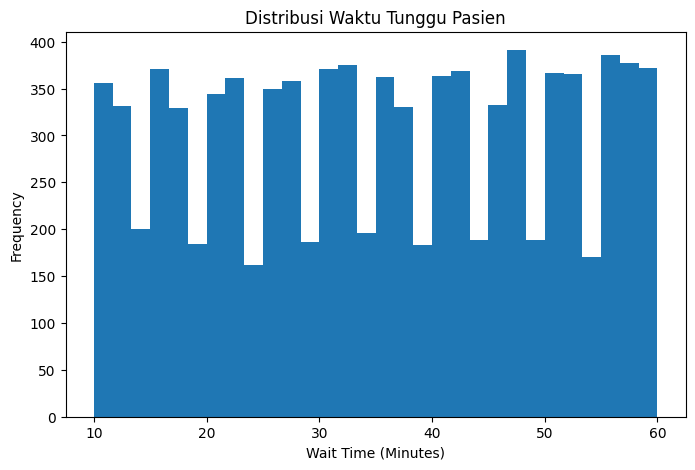

In [202]:
plt.figure(figsize=(8, 5))

plt.hist(df2_selected["patientwaittime"], bins=30)

plt.title("Distribusi Waktu Tunggu Pasien")

plt.xlabel("Wait Time (Minutes)")

plt.ylabel("Frequency")

plt.show()


RATA-RATA DELAY PER DEPARTMENT

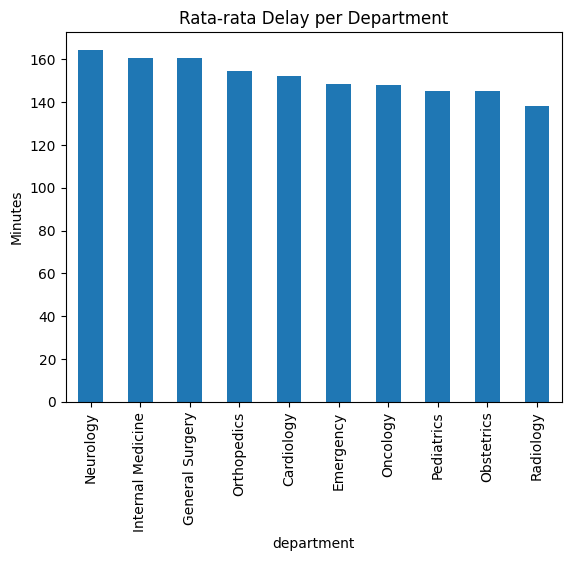

In [203]:
avg_delay = (
    df1_selected
    .groupby("department")["totaldelaytime"]
    .mean()
    .sort_values(ascending=False)
)

avg_delay.plot(kind="bar")

plt.title("Rata-rata Delay per Department")

plt.ylabel("Minutes")

plt.show()

DISTRIBUSI DELAY TIME

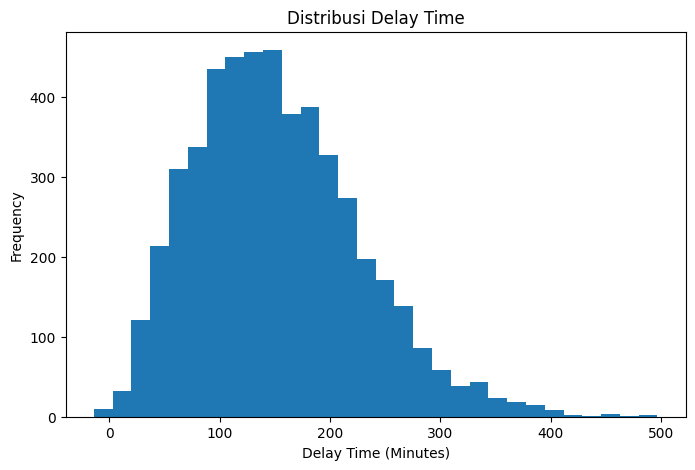

In [204]:
plt.figure(figsize=(8,5))

plt.hist(
    df1_selected["totaldelaytime"],
    bins=30
)

plt.title("Distribusi Delay Time")
plt.xlabel("Delay Time (Minutes)")
plt.ylabel("Frequency")

plt.show()

OCCUPANCY RATE & DELAY

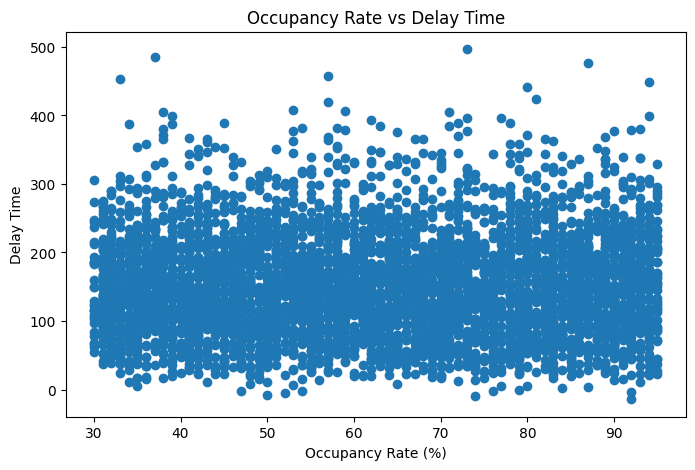

In [205]:
plt.figure(figsize=(8,5))

plt.scatter(
    df1_selected["facilityoccupancyrate"],
    df1_selected["totaldelaytime"]
)

plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Delay Time")
plt.title("Occupancy Rate vs Delay Time")

plt.show()

## Dimensional Modeling Star Schema

DIMENSION TABLE - DIM_TIME

In [206]:
all_dates = pd.concat([
df1_selected[["date"]],
df2_selected[["date"]],
df3_selected[["date"]]
])

dim_time = (
all_dates
.drop_duplicates()
.reset_index(drop=True)
)

dim_time["date"] = pd.to_datetime(dim_time["date"])

dim_time["year"] = (dim_time["date"].dt.year)
dim_time["month"] = (dim_time["date"].dt.month)
dim_time["day"] = (dim_time["date"].dt.day)
dim_time["quarter"] = (dim_time["date"].dt.quarter)

dim_time["time_key"] = range(1, len(dim_time)+1)

dim_time["date"] = dim_time["date"].dt.date

dim_time = dim_time[[
"time_key",
"date",
"year",
"month",
"day",
"quarter"
]]

dim_time


,time_key,date,year,month,day,quarter
0,1,2024-03-15,2024,3,15,1
1,2,2024-01-01,2024,1,1,1
2,3,2024-01-19,2024,1,19,1
3,4,2024-03-27,2024,3,27,1
4,5,2024-03-10,2024,3,10,1
...,...,...,...,...,...,...
2552,2553,2024-12-27,2024,12,27,4
2553,2554,2024-12-28,2024,12,28,4
2554,2555,2024-12-29,2024,12,29,4
2555,2556,2024-12-30,2024,12,30,4


DIMENSION TABLE - DIM PATIENT

In [207]:
patient1 = df1_selected[[
    "patient_id",
    "agegroup",
    "insurancetype"
]].copy()

patient1["patient_gender"] = "Unknown"
patient1["patient_race"] = "Unknown"


patient2 = df2_selected[[
    "patientid",
    "agegroup",
    "patientgender",
    "patientrace"
]].copy()

patient2 = patient2.rename(columns={
    "patientid": "patient_id",
    "patientgender": "patient_gender",
    "patientrace": "patient_race"
})

patient2["insurancetype"] = "Unknown"


patient2 = patient2[[
    "patient_id",
    "agegroup",
    "insurancetype",
    "patient_gender",
    "patient_race"
]]

dim_patient = pd.concat(
    [patient1, patient2],
    ignore_index=True
)

dim_patient = (
    dim_patient
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_patient["patient_key"] = range(
    1,
    len(dim_patient)+1
)

dim_patient = dim_patient[[
    "patient_key",
    "patient_id",
    "agegroup",
    "patient_gender",
    "patient_race",
    "insurancetype"
]]

dim_patient

,patient_key,patient_id,agegroup,patient_gender,patient_race,insurancetype
0,1,P100000,Adult (36-60),Unknown,Unknown,Private
1,2,P100001,Adult (36-60),Unknown,Unknown,Self-Pay
2,3,P100002,Young Adult (18-35),Unknown,Unknown,Medicaid
3,4,P100003,Adult (36-60),Unknown,Unknown,Unknown
4,5,P100004,Senior (61+),Unknown,Unknown,Medicare
...,...,...,...,...,...,...
14211,14212,353-25-3957,Young Adult (18-35),Male,White,Unknown
14212,14213,608-47-0337,Young Adult (18-35),Female,White,Unknown
14213,14214,716-90-5923,Young,Female,African American,Unknown
14214,14215,641-52-3173,Adult (36-60),Female,White,Unknown


In [208]:
dim_patient.isnull().sum()

,0
patient_key,0
patient_id,0
agegroup,0
patient_gender,0
patient_race,0
insurancetype,0


DIMENSION TABLE - DIM HOSPITAL

In [209]:
dim_hospital = pd.DataFrame()

dim_hospital["department"] = (
    pd.concat([
        df1_selected["department"],
        df2_selected["department"]
    ])
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_hospital["hospital_key"] = range(
    1,
    len(dim_hospital)+1
)

dim_hospital = dim_hospital[[
    "hospital_key",
    "department"
]]

dim_hospital

,hospital_key,department
0,1,Orthopedics
1,2,Cardiology
2,3,General Surgery
3,4,Emergency
4,5,Radiology
5,6,Obstetrics
6,7,Neurology
7,8,Oncology
8,9,Pediatrics
9,10,Internal Medicine


In [210]:
#Hasil Integrasi dari DIM_HOSPITAL
print(
    pd.concat([
        df1_selected["department"],
        df2_selected["department"]
    ]).shape
)

(14216,)


In [211]:
#Tabel Unik yang Terbentuk dan Diketahui
print(
    pd.concat([
        df1_selected["department"],
        df2_selected["department"]
    ]).nunique()
)

15


DIMENSION TABLE - DIM_EMERGENCY

In [212]:
dim_emergency = df3_selected[[
"incident_severity",
"traffic_congestion",
"weather_condition",
"road_type",
"emergency_level"
]]

dim_emergency = (
dim_emergency
.drop_duplicates()
.reset_index(drop=True)
)

dim_emergency["emergency_key"] = range(
1,
len(dim_emergency)+1
)

dim_emergency = dim_emergency[[
"emergency_key",
"incident_severity",
"traffic_congestion",
"weather_condition",
"road_type",
"emergency_level"
]]

dim_emergency

,emergency_key,incident_severity,traffic_congestion,weather_condition,road_type,emergency_level
0,1,Low,High,Clear,Highway,Major
1,2,Low,Moderate,Clear,Highway,Critical
2,3,Medium,High,Rainy,Unpaved Road,Minor
3,4,Low,Moderate,Clear,Highway,Minor
4,5,Low,Moderate,Stormy,Highway,Minor
...,...,...,...,...,...,...
238,239,Medium,High,Stormy,Unpaved Road,Critical
239,240,High,High,Rainy,Unpaved Road,Major
240,241,High,High,Stormy,Unpaved Road,Critical
241,242,High,High,Stormy,Local Road,Critical


## FACT TABLE - FACT_REFERRAL

In [213]:
fact_referral = pd.DataFrame()

FOREIGN KEY

In [214]:
fact_referral["time_key"] = (
    df_merged["date"]
    .map(dim_time.set_index("date")["time_key"])
)

patient_key_map = (
    dim_patient
    .drop_duplicates(subset="patient_id")
    .set_index("patient_id")["patient_key"]
)

fact_referral["patient_key"] = (
    df_merged["patient_id"]
    .map(patient_key_map)
)

fact_referral["hospital_key"] = (
    df_merged["department"]
    .map(dim_hospital.set_index("department")["hospital_key"])
)


METRIC FACT TABLE

In [215]:
fact_referral["consultation_duration"] = (
    df_merged["consultationdurationtime"]
)

fact_referral["total_hospital_time"] = (
    df_merged["totaltimeinhospital"]
)

fact_referral["total_delay_time"] = (
    df_merged["totaldelaytime"]
)

fact_referral["total_referral_time"] = (
    fact_referral["consultation_duration"]
    +
    fact_referral["total_delay_time"]
)

fact_referral["facility_occupancy_rate"] = (
    df_merged["facilityoccupancyrate"]
)

fact_referral["providers_on_shift"] = (
    df_merged["providersonshift"]
)

fact_referral["nurses_on_shift"] = (
    df_merged["nursesonshift"]
)

fact_referral["patient_wait_time"] = (
    df_merged["avg_patient_wait_time"]
)

fact_referral["avg_response_time"] = (
    df_merged["response_time"]
)

fact_referral["avg_distance_to_incident"] = (
    df_merged["distance_to_incident"]
)

fact_referral["emergency_key"] = (
    (pd.RangeIndex(len(df_merged)) % len(dim_emergency)) + 1
)

PRIMARY KEY FACT TABLE

In [216]:
fact_referral["fact_id"] = range(
    1,
    len(fact_referral)+1
)


## Sorting Kolom Fact Table

In [217]:
fact_referral["patient_wait_time"] = (
    df_merged["avg_patient_wait_time"]
)

fact_referral = fact_referral[[
    "fact_id",
    "time_key",
    "patient_key",
    "hospital_key",
    "emergency_key",
    "consultation_duration",
    "total_hospital_time",
    "total_delay_time",
    "total_referral_time",
    "patient_wait_time",
    "avg_response_time",
    "avg_distance_to_incident",
    "facility_occupancy_rate",
    "providers_on_shift",
    "nurses_on_shift"
]]

fact_referral


,fact_id,time_key,patient_key,hospital_key,emergency_key,consultation_duration,total_hospital_time,total_delay_time,total_referral_time,patient_wait_time,avg_response_time,avg_distance_to_incident,facility_occupancy_rate,providers_on_shift,nurses_on_shift
0,1,1,1,1,1,22.33,151.75,123.77,146.10,33.92,14.98,24.86,32.0,6,14
1,2,2,2,2,2,20.45,141.05,128.58,149.03,37.79,15.05,26.90,56.0,7,13
2,3,3,3,3,3,20.97,387.05,376.70,397.67,41.60,15.13,27.28,90.0,4,7
3,4,4,4,4,4,5.00,37.18,37.12,42.12,39.41,15.44,25.21,41.0,5,4
4,5,5,5,2,5,5.33,223.08,222.85,228.18,40.22,14.32,23.90,66.0,8,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,46,4996,9,136,32.60,105.47,73.13,105.73,42.62,15.17,25.23,48.0,2,12
4996,4997,40,4997,8,137,17.72,253.68,248.92,266.64,43.17,14.04,24.35,54.0,8,11
4997,4998,8,4998,8,138,8.53,159.65,138.25,146.78,38.78,14.78,25.42,89.0,5,12
4998,4999,74,4999,7,139,9.05,99.53,112.25,121.30,35.64,15.21,26.11,58.0,6,14


## ERD Star Schema

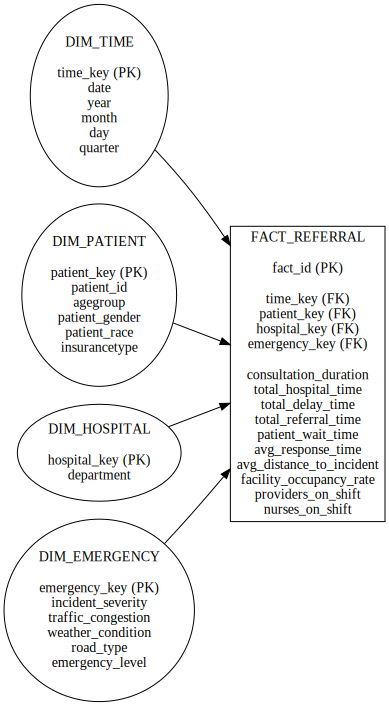

In [218]:
erd = Digraph(
    "HospitalReferralDW",
    format="png"
)

erd.attr(rankdir="LR")

# FACT TABLE
erd.node(
    "F",
    """FACT_REFERRAL

fact_id (PK)

time_key (FK)
patient_key (FK)
hospital_key (FK)
emergency_key (FK)

consultation_duration
total_hospital_time
total_delay_time
total_referral_time
patient_wait_time
avg_response_time
avg_distance_to_incident
facility_occupancy_rate
providers_on_shift
nurses_on_shift
""",
    shape="box"
)

# DIM TIME
erd.node(
    "T",
    """DIM_TIME

time_key (PK)
date
year
month
day
quarter
""",
    shape="ellipse"
)

# DIM PATIENT
erd.node(
    "P",
    """DIM_PATIENT

patient_key (PK)
patient_id
agegroup
patient_gender
patient_race
insurancetype
""",
    shape="ellipse"
)

# DIM HOSPITAL
erd.node(
    "H",
    """DIM_HOSPITAL

hospital_key (PK)
department
""",
    shape="ellipse"
)

# DIM EMERGENCY
erd.node(
    "E",
    """DIM_EMERGENCY

emergency_key (PK)
incident_severity
traffic_congestion
weather_condition
road_type
emergency_level
""",
    shape="ellipse"
)

erd.edge("T", "F")
erd.edge("P", "F")
erd.edge("H", "F")
erd.edge("E", "F")

erd


ETL VALIDATION

In [219]:
print("Dim Time :", dim_time.shape)
print("Dim Patient :", dim_patient.shape)
print("Dim Hospital :", dim_hospital.shape)
print("Dim Emergency :", dim_emergency.shape)
print("Fact Referral :", fact_referral.shape)

Dim Time : (2557, 6)
Dim Patient : (14216, 6)
Dim Hospital : (15, 2)
Dim Emergency : (243, 6)
Fact Referral : (5000, 15)


## Load Datawarehouse ke SQLITE

In [220]:
conn = sqlite3.connect("hospital_referral_dw.db")

LOAD DIMENSION TABLE

In [221]:
dim_time.to_sql(
    "dim_time",
    conn,
    if_exists="replace",
    index=False
)

dim_patient.to_sql(
    "dim_patient",
    conn,
    if_exists="replace",
    index=False
)

dim_hospital.to_sql(
    "dim_hospital",
    conn,
    if_exists="replace",
    index=False
)

dim_emergency.to_sql(
    "dim_emergency",
    conn,
    if_exists="replace",
    index=False
)

243

LOAD FACT TABLE

In [222]:
fact_referral.to_sql(
    "fact_referral",
    conn,
    if_exists="replace",
    index=False
)

5000

SIMPAN DAN TUTUP KONEKSI

In [223]:
conn.commit()
conn.close()

## SQL Analysis

In [224]:
conn = sqlite3.connect("hospital_referral_dw.db")

RATA-RATA WAKTU DI RUMAH SAKIT

In [225]:
query1 = """
SELECT AVG(total_hospital_time)
AS avg_hospital_time
FROM fact_referral
"""

result1 = pd.read_sql_query(query1,conn)

print(result1)

   avg_hospital_time
0         164.212802


RATA-RATA DELAY PASIEN

In [226]:
query2 = """
SELECT AVG(total_delay_time)
AS avg_delay_time
FROM fact_referral
"""

result2 = pd.read_sql_query(query2,conn)

print(result2)

   avg_delay_time
0      151.843042


JUMLAH RUJUKAN PER DEPARTMENT

In [227]:
query3 = """
SELECT
    h.department,
    COUNT(f.fact_id) AS total_referral
FROM fact_referral f
JOIN dim_hospital h
ON f.hospital_key = h.hospital_key
GROUP BY h.department
ORDER BY total_referral DESC
"""

result3 = pd.read_sql_query(query3, conn)

print(result3)


          department  total_referral
0           Oncology             530
1         Pediatrics             527
2    General Surgery             506
3  Internal Medicine             505
4          Neurology             499
5        Orthopedics             492
6          Radiology             489
7          Emergency             486
8         Cardiology             485
9         Obstetrics             481


RATA-RATA DEPARTMENT DENGAN WAKTU RUJUKAN TERTINGGI

In [228]:
query4 = """
SELECT
    d.department,
    AVG(f.total_referral_time)
        AS avg_referral_time
FROM fact_referral f
JOIN dim_hospital d
ON f.hospital_key = d.hospital_key
GROUP BY d.department
ORDER BY avg_referral_time DESC
"""

result4 = pd.read_sql_query(query4,conn)

print(result4)

          department  avg_referral_time
0          Neurology         183.129359
1    General Surgery         179.956047
2  Internal Medicine         179.369168
3        Orthopedics         173.585203
4         Cardiology         170.963649
5          Emergency         167.260947
6           Oncology         166.762151
7         Obstetrics         164.108649
8         Pediatrics         163.750664
9          Radiology         156.492883


SUMMARY QUERY

In [229]:
query5 = """
SELECT
    AVG(f.total_delay_time)
        AS avg_delay_time,
    AVG(f.total_hospital_time)
        AS avg_hospital_time,
    AVG(f.total_referral_time)
        AS avg_referral_time
FROM fact_referral f
"""

result5 = pd.read_sql_query(query5,conn)

print(result5)

   avg_delay_time  avg_hospital_time  avg_referral_time
0      151.843042         164.212802         170.554534


QUERY BISNIS: Departemen Paling Tidak Efisien dalam Waktu Rujukan

In [230]:
query_bisnis = """
SELECT
    h.department,
    COUNT(f.fact_id)                          AS jumlah_rujukan,
    ROUND(AVG(f.total_referral_time), 2)      AS avg_waktu_rujukan,
    ROUND(AVG(f.patient_wait_time), 2)        AS avg_waktu_tunggu,
    ROUND(AVG(f.avg_response_time), 2)        AS avg_waktu_perjalanan
FROM fact_referral f
JOIN dim_hospital h
    ON f.hospital_key = h.hospital_key
GROUP BY h.department
ORDER BY avg_waktu_rujukan DESC
LIMIT 10
"""

result_bisnis = pd.read_sql_query(query_bisnis, conn)
print("Departemen dengan Waktu Rujukan Tertinggi")
print(result_bisnis)


Departemen dengan Waktu Rujukan Tertinggi
          department  jumlah_rujukan  avg_waktu_rujukan  avg_waktu_tunggu  \
0          Neurology             499             183.13             36.36   
1    General Surgery             506             179.96             36.09   
2  Internal Medicine             505             179.37             36.28   
3        Orthopedics             492             173.59             36.55   
4         Cardiology             485             170.96             36.48   
5          Emergency             486             167.26             36.58   
6           Oncology             530             166.76             36.52   
7         Obstetrics             481             164.11             36.24   
8         Pediatrics             527             163.75             36.50   
9          Radiology             489             156.49             36.28   

   avg_waktu_perjalanan  
0                 15.05  
1                 15.04  
2                 15.04  
3     

In [231]:
conn.close()


## Hasil Akhir

In [232]:
print(dim_time.head())

   time_key        date  year  month  day  quarter
0         1  2024-03-15  2024      3   15        1
1         2  2024-01-01  2024      1    1        1
2         3  2024-01-19  2024      1   19        1
3         4  2024-03-27  2024      3   27        1
4         5  2024-03-10  2024      3   10        1


In [233]:
print(dim_patient.head())

   patient_key patient_id             agegroup patient_gender patient_race  \
0            1    P100000        Adult (36-60)        Unknown      Unknown   
1            2    P100001        Adult (36-60)        Unknown      Unknown   
2            3    P100002  Young Adult (18-35)        Unknown      Unknown   
3            4    P100003        Adult (36-60)        Unknown      Unknown   
4            5    P100004         Senior (61+)        Unknown      Unknown   

  insurancetype  
0       Private  
1      Self-Pay  
2      Medicaid  
3       Unknown  
4      Medicare  


In [234]:
print(dim_hospital.head())

   hospital_key       department
0             1      Orthopedics
1             2       Cardiology
2             3  General Surgery
3             4        Emergency
4             5        Radiology


In [235]:
print(dim_emergency.head())

   emergency_key incident_severity traffic_congestion weather_condition  \
0              1               Low               High             Clear   
1              2               Low           Moderate             Clear   
2              3            Medium               High             Rainy   
3              4               Low           Moderate             Clear   
4              5               Low           Moderate            Stormy   

      road_type emergency_level  
0       Highway           Major  
1       Highway        Critical  
2  Unpaved Road           Minor  
3       Highway           Minor  
4       Highway           Minor  


In [236]:
print(fact_referral.head())

   fact_id  time_key  patient_key  hospital_key  emergency_key  \
0        1         1            1             1              1   
1        2         2            2             2              2   
2        3         3            3             3              3   
3        4         4            4             4              4   
4        5         5            5             2              5   

   consultation_duration  total_hospital_time  total_delay_time  \
0                  22.33               151.75            123.77   
1                  20.45               141.05            128.58   
2                  20.97               387.05            376.70   
3                   5.00                37.18             37.12   
4                   5.33               223.08            222.85   

   total_referral_time  patient_wait_time  avg_response_time  \
0               146.10              33.92              14.98   
1               149.03              37.79              15.05   
2       